# Avaliação do modelo — Copiloto de verificação em saúde (Grupo 04)

Notebook do entregável de 09/10/2026 (change `add-notebook-avaliacao-modelo`).

**O que é "o modelo" aqui.** O projeto não treina classificador de veredito
(`openspec/project.md`, revisão de 10/09/2026). O componente avaliável é o
**mecanismo de recuperação**: um índice híbrido BM25 + `intfloat/multilingual-e5-base`
sobre checagens do FactCenter, usado sem ajuste fino. O artefato salvo
equivalente a um modelo treinado é o índice em `prototipo/indice/`:

| Arquivo | Conteúdo |
| --- | --- |
| `densa.npy` | embeddings e5-base, uma linha por fragmento (768 dimensões, float32) |
| `fragmentos.jsonl` | texto e metadados de cada fragmento indexado |
| `unidades.jsonl` | unidades semânticas (alegação + veredito + fundamentação) |
| `vocabulario.json` | vocabulário do braço léxico |
| `manifesto.json` | composição declarada do índice (versionado) |

Os `.npy`/`.jsonl` não são versionados. Para reconstruir:
`python -m prototipo.rag construir` (cerca de 15 min no e5-base).

**Seções**

1. Carga do índice
2. Preparação dos dados
3. Aferição da recuperação (Recall@k, MRR, latência)
4. Calibração de alfa e validação leave-one-out
5. Busca de exemplo
6. Sondas do gerador (LLM)
7. Estudo piloto com usuários
8. Leitura dos resultados

As seções 1, 3, 4 e 5 executam o recuperador. As seções 2, 6 e 7 leem relatórios
versionados: as sondas exigem Ollama ou chave de API e o piloto exige
participantes, então o notebook mostra as medições registradas.
Nada é gravado no repositório.

In [1]:
import json
import os
import pathlib
import sys
import time
import warnings

import pandas as pd
import matplotlib.pyplot as plt

RAIZ = pathlib.Path.cwd()
while not (RAIZ / "openspec").exists() and RAIZ != RAIZ.parent:
    RAIZ = RAIZ.parent
os.chdir(RAIZ)
sys.path.insert(0, str(RAIZ))
# Com o e5-base já baixado, não consulta o Hugging Face a cada carga.
if (pathlib.Path.home() / ".cache/huggingface/hub/models--intfloat--multilingual-e5-base").exists():
    os.environ.setdefault("HF_HUB_OFFLINE", "1")

pd.set_option("display.max_colwidth", 120)
os.environ["TQDM_DISABLE"] = "1"  # sem barra de progresso na carga do e5-base
warnings.filterwarnings("ignore", module="tqdm")

def ler(caminho):
    return json.loads((RAIZ / caminho).read_text(encoding="utf-8"))

print("raiz do repositório:", RAIZ)

raiz do repositório: /Users/aluno2/Documents/Residencia/g04-notebook


## 1. Carga do índice

`carregar()` é a mesma função da CLI (`python -m prototipo.rag buscar`). Ela
confere que a matriz densa tem uma linha por fragmento, na mesma ordem, e para
a carga se não tiver (decisão 16 de `mvp-copiloto-verificacao`).

In [2]:
from prototipo.rag.__main__ import MATRIZ, carregar
from prototipo.rag.hibrida import ALFA_PADRAO, LIMIAR_EVIDENCIA

if not MATRIZ.exists():
    raise SystemExit("índice ausente — rode `python -m prototipo.rag construir` na raiz do repositório")

marca = time.perf_counter()
recuperador = carregar()
print(f"carga: {time.perf_counter() - marca:.1f} s")
print("matriz densa:", recuperador.denso.matriz.shape, recuperador.denso.matriz.dtype,
      f"({MATRIZ.stat().st_size / 1e6:.1f} MB)")
print("modelo de embedding:", recuperador.denso.modelo_nome)
print("alfa (peso do braço denso):", ALFA_PADRAO, "| piso de evidência:", LIMIAR_EVIDENCIA)

carga: 2.5 s
matriz densa: (23655, 768) float32 (72.7 MB)
modelo de embedding: intfloat/multilingual-e5-base
alfa (peso do braço denso): 0.9 | piso de evidência: 0.55


In [3]:
manifesto = ler("prototipo/indice/manifesto.json")
resumo = {k: v for k, v in manifesto.items() if not isinstance(v, (dict, list))}
display(pd.Series(resumo, name="manifesto").to_frame())
display(pd.DataFrame(manifesto["por_corpus"]).T)

,manifesto
registros_lidos,5047
unidades_indexadas,6279
fragmentos_indexados,23655
registros_em_quarentena,174
unidades_em_quarentena,6
busca,"exata, sem índice aproximado e sem banco vetorial (design.md, decisão 3)"
condicao_de_reabertura,crescimento do corpus em uma ordem de grandeza (dezenas de milhares de unidades)
fragmento_caracteres,1100
fragmento_sobreposicao,150
matriz_densa,estendida por `python -m prototipo.rag construir --estender` em 01/10/2026: 22463 linhas do FactCenter reaproveitada...


,registros_lidos,unidades,fragmentos,disposicoes,linhas_lidas,apto_citacao
factcenter_saude,4063,5089,22463,"{'unica': 3476, 'quarentena_misto': 88, 'nao_segmentada': 278, 'segmentada': 221}",NaN,NaN
factckbr,984,1190,1192,"{'quarentena_duplicata_factcenter': 74, 'unica': 813, 'quarentena_campo_vazio': 12, 'segmentada': 85, 'unidade_em_qu...",1313,False


## 2. Preparação dos dados

Medições do pipeline `tratamento/`, lidas dos relatórios em `datasets/derivados/`.
Os dados brutos (181 MB) não são versionados; para regenerar os relatórios:
`python -m tratamento integridade`, `python -m tratamento vereditos`,
`python -m tratamento frescor`.

### 2.1 Integridade textual (`integridade.py`)

Critério de corrupção: maiúscula acentuada com zero ocorrências enquanto a
minúscula correspondente tem pelo menos 500.

In [4]:
integridade = ler("datasets/derivados/relatorio_integridade.json")
linhas = []
for nome, r in integridade.items():
    if not isinstance(r, dict) or "caracteres" not in r:
        continue
    linhas.append({
        "arquivo": nome,
        "caracteres": r["caracteres"],
        "maiúsculas ausentes": len(r["ausentes"]),
        "corrompidas": "".join(x["maiuscula"] for x in r["corrompidos"]) or "—",
        "ã / Ã": f'{r["contagem_por_letra_minuscula"]["ã"]} / {r["contagem_por_letra"]["Ã"]}',
        "aprovado": r["aprovado"],
    })
pd.DataFrame(linhas)

,arquivo,caracteres,maiúsculas ausentes,corrompidas,ã / Ã,aprovado
0,factcenter_subset_saude.csv,21559001,1,—,139108 / 3539,True
1,factckbr_normalizado.csv,719266,11,ÃÊÍÓÕÚÇ,3625 / 0,False
2,fakerecogna2_subset_saude_ciencia.csv,23648777,3,ÊÕ,127670 / 7,False
3,fakerecogna2_amostra_estimulos_300.csv,284006,9,ÃÇ,1521 / 0,False


### 2.2 Normalização de vereditos (`mapa_vereditos.json`)

In [5]:
vereditos = ler("datasets/derivados/relatorio_vereditos.json")
campos = ["mapa_versao", "registros", "strings_brutas_distintas", "grafias_distintas",
          "chaves_canonicas_distintas", "registros_mistos"]
display(pd.Series({k: vereditos[k] for k in campos}).to_frame("valor"))

rotulos = pd.Series(vereditos["por_rotulo_consolidado"], name="registros")
display(rotulos.to_frame().assign(proporcao=lambda d: (d.registros / vereditos["registros"]).round(3)))

boato = vereditos["grafias"]["boato"]
print(f'rótulo "boato" (Boatos.org): {boato} de {vereditos["registros"]} = {boato / vereditos["registros"]:.1%}')

,valor
mapa_versao,1.0.0
registros,4063
strings_brutas_distintas,285
grafias_distintas,26
chaves_canonicas_distintas,19
registros_mistos,245


,registros,proporcao
falso,3419,0.841
verdadeiro fora de contexto ou exagerado,363,0.089
verdadeiro,21,0.005
nao_mapeavel,15,0.004


rótulo "boato" (Boatos.org): 1744 de 4063 = 42.9%


### 2.3 Frescor e cobertura temporal (`frescor.py`)

janela: {'inicio': '2013-07-08', 'fim': '2021-05-19'} | registros: 4063
ano de maior concentração: 2020 (2188 registros, 53.9%)
termos com zero ocorrência: mpox, oropouche, qdenga, semaglutida


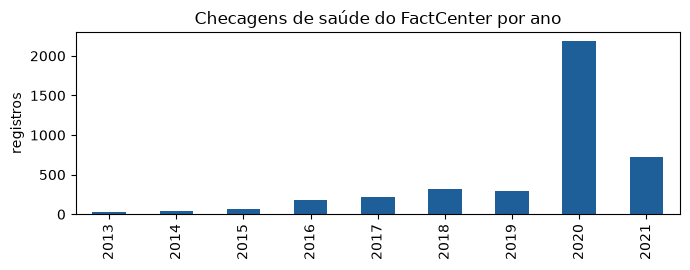

In [6]:
cobertura = ler("datasets/derivados/declaracao_cobertura.json")
print("janela:", cobertura["janela"], "| registros:", cobertura["registros"])
c = cobertura["concentracao_maxima"]
print(f'ano de maior concentração: {c["ano"]} ({c["registros"]} registros, {c["proporcao"]:.1%})')
print("termos com zero ocorrência:", ", ".join(cobertura["termos_com_zero_ocorrencia"]))

fig, ax = plt.subplots(figsize=(7, 2.8))
pd.Series(cobertura["por_ano"]).plot.bar(ax=ax, color="#1f5f99")
ax.set_title("Checagens de saúde do FactCenter por ano")
ax.set_ylabel("registros")
plt.tight_layout()

## 3. Aferição da recuperação

Conjunto: 20 consultas reais de desinformação fora do recorte de COVID-19
(`prototipo/rag/consultas_afericao.json`), metade verbatim e metade reformulada
em linguagem coloquial. Para cada consulta, a checagem correta é conhecida.

- **Recall@k**: fração das consultas em que a checagem correta aparece entre os k primeiros resultados.
- **MRR**: média de 1/posição da checagem correta (0 se não aparece no top-10).
- **Latência**: mediana por consulta, só a busca (sem o gerador).

`aferir_tudo` é a função usada pela CLI `aferir`; aqui o resultado fica em memória
e é comparado com a medição versionada.

In [7]:
from prototipo.rag import afericao

consultas = afericao.carregar_consultas()
display(pd.DataFrame(consultas["consultas"])[["id", "familia", "consulta"]].head(6))

resultado = afericao.aferir_tudo(recuperador)

def tabela(por_modo):
    return pd.DataFrame({
        modo: {**{f"Recall{k}": v["recall"][k] for k in ("@1", "@3", "@5", "@10")},
               "MRR": v["mrr"], "latência mediana (ms)": round(v["latencia_s"]["mediana"] * 1000)}
        for modo, v in por_modo.items()
    }).T

agora = tabela(resultado["por_modo"])
agora

,id,familia,consulta
0,a01,verbatim,O vírus da febre amarela sofreu uma mutação e a vacina não protege mais
1,a02,verbatim,A vacina da gripe é um veneno mortal
2,a03,verbatim,Vacina contra H1N1 causa narcolepsia
3,a04,verbatim,Adultos têm que tomar a vacina contra o sarampo mesmo tendo se vacinado na infância
4,a05,verbatim,A vacina contra febre amarela mata em 50% dos casos
5,a06,verbatim,Vacina contra febre amarela causa perda de visão e cegueira


,Recall@1,Recall@3,Recall@5,Recall@10,MRR,latência mediana (ms)
lexica,0.60,0.85,0.85,0.85,0.725,26.0
densa,0.80,0.95,1.00,1.00,0.877,17.0
hibrida,0.85,0.90,1.00,1.00,0.897,40.0
hibrida_rrf,0.85,0.85,0.85,0.90,0.855,44.0


In [8]:
versionado = tabela(ler("prototipo/indice/afericao_multilingual-e5-base.json")["por_modo"])
metricas = [c for c in agora.columns if c != "latência mediana (ms)"]
iguais = (agora[metricas] == versionado[metricas]).all().all()
print("Recall@k e MRR iguais à medição versionada:", iguais)
pd.concat({"recalculado": agora, "versionado": versionado}, axis=1).swaplevel(axis=1).sort_index(axis=1)[["MRR", "Recall@1", "Recall@5"]]

Recall@k e MRR iguais à medição versionada: True


MRR               Recall@1               Recall@5  \
            recalculado versionado recalculado versionado recalculado   
lexica            0.725      0.725        0.60       0.60        0.85   
densa             0.877      0.877        0.80       0.80        1.00   
hibrida           0.897      0.897        0.85       0.85        1.00   
hibrida_rrf       0.855      0.855        0.85       0.85        0.85   

                        
            versionado  
lexica            0.85  
densa             1.00  
hibrida           1.00  
hibrida_rrf       0.85

### 3.1 Por família de consulta

Medir só com consultas verbatim favorece o BM25; só com reformuladas favorece o
braço denso. A separação mostra onde cada braço falha.

In [9]:
familias = pd.DataFrame({
    (modo, familia): {"Recall@1": v["recall"]["@1"], "Recall@5": v["recall"]["@5"], "MRR": v["mrr"]}
    for modo, por_familia in resultado["por_familia"].items()
    for familia, v in por_familia.items()
}).T
familias

Recall@1  Recall@5    MRR
lexica  reformulada       0.4       0.7  0.550
        verbatim          0.8       1.0  0.900
densa   reformulada       0.7       1.0  0.803
        verbatim          0.9       1.0  0.950
hibrida reformulada       0.8       1.0  0.845
        verbatim          0.9       1.0  0.950

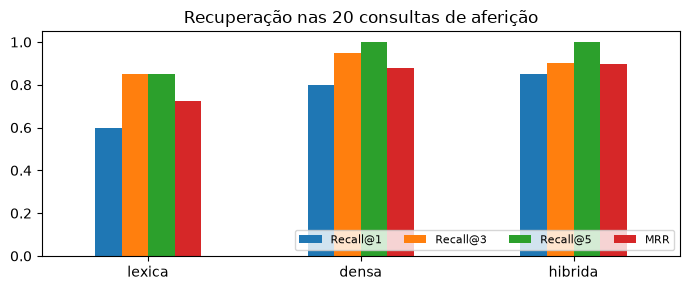

In [10]:
fig, ax = plt.subplots(figsize=(7, 3))
agora.loc[["lexica", "densa", "hibrida"], ["Recall@1", "Recall@3", "Recall@5", "MRR"]].plot.bar(ax=ax, rot=0)
ax.set_ylim(0, 1.05)
ax.set_title("Recuperação nas 20 consultas de aferição")
ax.legend(ncol=4, fontsize=8, loc="lower right")
plt.tight_layout()

### 3.2 Posição da checagem correta, consulta a consulta

A híbrida não domina a densa em todo corte: no Recall@3 uma consulta desce da
posição 3 para a 4. O ganho da híbrida está em levar mais checagens à posição 1.

In [11]:
posicoes = pd.DataFrame({m: resultado["por_modo"][m]["posicoes"] for m in ("lexica", "densa", "hibrida")})
familia = {c["id"]: c["familia"] for c in consultas["consultas"]}
posicoes.insert(0, "familia", posicoes.index.map(familia))
posicoes[posicoes[["lexica", "densa", "hibrida"]].ne(1).any(axis=1)]

,familia,lexica,densa,hibrida
a02,verbatim,2.0,2,2
a07,verbatim,2.0,1,1
a12,reformulada,2.0,2,1
a14,reformulada,NaN,5,5
a15,reformulada,2.0,1,1
a16,reformulada,NaN,3,4
a18,reformulada,2.0,1,1
a20,reformulada,NaN,1,1


## 4. Calibração de alfa e validação leave-one-out

Fusão: `alfa × denso + (1 − alfa) × léxico` sobre escores normalizados. A
primeira medição, com alfa = 0,5, concluiu que a híbrida perdia da densa pura.
A varredura mostrou que o problema era o 0,5. Para não confundir ajuste à
amostra com ganho real, o leave-one-out escolhe alfa em 19 consultas e avalia
na que ficou de fora.

melhor alfa: 0.98 | platô: [0.9, 0.92, 0.94, 0.96, 0.98]
leave-one-out: MRR híbrida 0.8975 vs densa pura 0.8767 | híbrida ganha fora da amostra: True
versionado: 0.8975 vs 0.8767


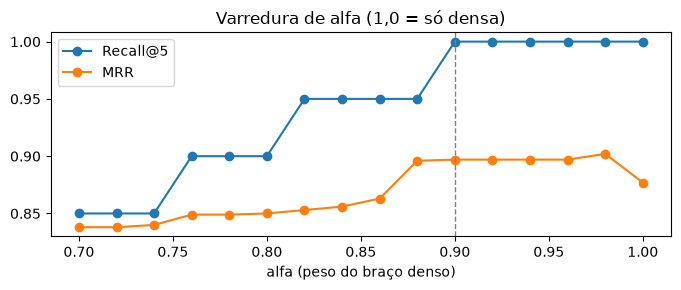

In [12]:
varredura = afericao.varrer_alfa(recuperador)
curva = pd.DataFrame({float(a): {"Recall@5": v["recall"]["@5"], "MRR": v["mrr"]}
                      for a, v in varredura["por_alfa"].items()}).T

fig, ax = plt.subplots(figsize=(7, 3))
curva.plot(ax=ax, marker="o")
ax.axvline(ALFA_PADRAO, color="gray", ls="--", lw=1)
ax.set_xlabel("alfa (peso do braço denso)")
ax.set_title("Varredura de alfa (1,0 = só densa)")
plt.tight_layout()

loo = varredura["leave_one_out"]
print("melhor alfa:", varredura["melhor_alfa"], "| platô:", varredura["dentro_de_0_01_do_topo"])
print(f'leave-one-out: MRR híbrida {loo["mrr_validado"]} vs densa pura {loo["mrr_densa_pura"]}',
      "| híbrida ganha fora da amostra:", loo["hibrida_ganha_fora_da_amostra"])

versionada = ler("prototipo/indice/varredura_alfa_multilingual-e5-base.json")["leave_one_out"]
print("versionado:", versionada["mrr_validado"], "vs", versionada["mrr_densa_pura"])

## 5. Busca de exemplo

`recuperar` é o caminho que o sistema usa: aplica a prioridade de idioma e
decide se a evidência cobre a consulta (piso sobre o escore fundido).
A terceira consulta é fora de domínio.

In [13]:
def mostrar(consulta, k=3):
    marca = time.perf_counter()
    r = recuperador.recuperar(consulta, k=k)
    custo = (time.perf_counter() - marca) * 1000
    print(f"\n>>> {consulta!r}  ({custo:.0f} ms, coberto: {'sim' if r.coberto else 'não'})")
    for i, a in enumerate(r.resultados, 1):
        print(f'{i}. {a["score"]:.3f}  [{a["veredito_original"]}] {a["agencia"]}, {a["data_publicacao"]}')
        print(f'   {a["alegacao"][:110]}')

for consulta in ["vacina altera o DNA da pessoa",
                 "a vacina da febre amarela mata mais que a doença",
                 "como declarar imposto de renda atrasado"]:
    mostrar(consulta)


>>> 'vacina altera o DNA da pessoa'  (55 ms, coberto: sim)
1. 0.623  [FALSO] lupa, 2020-10-21
   Essa será a primeira vacina da historia da humanidade a mexer com o nosso DNA
2. 0.618  [boato] boatos, 2020-08-18
   Bill Gates afirmou que vacina contra Covid-19 vai alterar o DNA das pessoas #boato
3. 0.614  [boato] boatos, 2020-08-04
   Vacina contra a Covid-19 vai modificar o DNA das pessoas e nos transformar em seres geneticamente modificados 

>>> 'a vacina da febre amarela mata mais que a doença'  (33 ms, coberto: sim)
1. 0.659  [boato] boatos, 2018-01-28
   Vacina contra febre amarela paralisa o fígado, diz médico de Sorocaba #boato
2. 0.656  [boato] boatos, 2018-01-20
   Enfermeira alerta que ninguém deve tomar a vacina contra febre amarela #boato
3. 0.655  [boato] boatos, 2018-01-30
   7 boatos sobre a febre amarela que sempre enganam os menos informados

>>> 'como declarar imposto de renda atrasado'  (41 ms, coberto: sim)
1. 0.664  [boato] boatos, 2020-10-02
   Celso de Mello s

## 6. Sondas do gerador (LLM)

Cada etapa que usa o LLM foi validada com o Gemma 4 12B local (`think: false`),
três tentativas por caso. Os números contam tentativas. Reexecutar exige Ollama
(`python -m prototipo.sonda_resposta` e equivalentes); aqui lemos os relatórios versionados.

A sonda `sem_evidencia` é anterior à correção `fix-resposta-sem-evidencia` e
fica na tabela porque motivou essa correção; a forma atual dessas respostas é
coberta pela sonda `resposta` (casos S1–S3).

In [14]:
import glob

linhas = []
for arquivo in sorted(glob.glob("prototipo/relatorio_sonda_*.json")):
    dados = ler(arquivo)
    if not isinstance(dados.get("sondas"), list):
        continue
    tentativas = [t for s in dados["sondas"] for t in s["tentativas"]]
    linhas.append({
        "sonda": arquivo.split("relatorio_sonda_")[1].removesuffix(".json"),
        "casos": len(dados["sondas"]),
        "aprovadas": sum(t["passou"] for t in tentativas),
        "tentativas": len(tentativas),
        "modelo": dados["modelo"],
        "gerado_em": dados["gerado_em"],
    })
pd.DataFrame(linhas)

,sonda,casos,aprovadas,tentativas,modelo,gerado_em
0,classificacao_guarda,8,24,24,gemma4:12b-it-qat,2026-10-06 09:46
1,extracao_decomposicao,7,21,21,gemma4:12b-it-qat,2026-10-06 09:43
2,fronteira,14,42,42,gemma4:12b-it-qat,2026-09-29 10:11
3,resposta,7,21,21,gemma4:12b-it-qat,2026-10-06 10:09
4,sem_evidencia,4,3,12,gemma4:12b-it-qat,2026-09-28 18:48


**Bancada ponta a ponta com a API DeepSeek (`deepseek-v4-pro`), 08/10/2026:**
27 de 27 casos na rodada final (a anterior, com o mesmo código, deu 26 de 27);
latência mediana por verificação completa de 9,1 s a 11,6 s nas oito rodadas,
contra 102,4 s do Gemma 4 local. Fonte: `openspec/changes/add-gerador-api-deepseek/design.md`.
Reexecutar: `python -m bancada rodar` com a chave da API.

## 7. Estudo piloto com usuários

Duas sessões (P-01, P-02), cujo objetivo é testar o instrumento antes da coleta
com 20 a 30 participantes. Nenhum número abaixo sustenta conclusão sobre efeito.

In [15]:
piloto = ler("datasets/relatorios_mvp_copiloto/relatorios_metricas.json")["agregado"]["piloto"]
print("sessões:", piloto["sessoes"])
res = piloto["resultado"]
taxas = {k: f'{v["n"]} de {v["de"]}' for k, v in res.items()
         if isinstance(v, dict) and {"n", "de"} <= v.keys()}
display(pd.Series(taxas, name="resultado").to_frame())
print("tempo até decisão fundamentada (mediana, s):",
      {k: (v["mediana"], f'n={v["n"]}') for k, v in res["tempo_decisao_fundamentada_s"].items()})

sessões: 2


,resultado
discernimento,4 de 4
transferencia,4 de 4
transferencia_com_criterio,4 de 4
abriu_camada_detalhe,6 de 6


tempo até decisão fundamentada (mediana, s): {'com_ferramenta': (137.5, 'n=6'), 'transferencia': (80.5, 'n=4')}


## 8. Leitura dos resultados

- **A recuperação encontra a checagem certa.** A híbrida calibrada (alfa = 0,9)
  põe a checagem correta no top-5 nas 20 consultas e no topo em 17. O ganho
  sobre a densa pura é pequeno (MRR 0,897 contra 0,877) e se mantém no
  leave-one-out; a densa pura é melhor em Recall@3.
- **O BM25 sozinho falha nas reformuladas**, que é como o público pergunta. É
  por isso que o braço denso tem peso 0,9.
- **Com 20 consultas, cada uma vale 0,05** nas métricas. As diferenças entre
  densa e híbrida são indicativas.
- **O escore não separa fora de domínio**: a consulta sobre imposto de renda
  recebe escore alto. Por isso a lacuna de acervo é decidida pela cobertura
  declarada e pelo modelo, e não só pelo piso de escore.
- **As sondas e a bancada** mostram que o gerador produz respostas na forma
  especificada; **o piloto** valida o instrumento, não o efeito no usuário.